# Solving an inverse problem with `odil_wave`

This notebook walks through a **frequency-domain full-waveform inversion (FWI)**
using the `odil_wave` building blocks, and recovers an unknown sound-speed map
`c(x, y)` from ring-array recordings.

The physics is the acoustic Helmholtz equation solved per temporal frequency,
`H(c, ω) u = f`. Inversion minimises a joint objective in the wavefield `u` and
the velocity `c`:

$$\mathcal{L} = w_\text{pde}\,\lVert r_\text{pde}(u,c)\rVert^2
  + w_\text{data}\,\lVert P u - d_\text{obs}\rVert^2 + w_\text{reg}\,R(c).$$

We use the same submodules covered by the test-suite: `grid`, `source`,
`geometry`, `models`, `loss`, plus the `operator` (Helmholtz) and `optimisation`
(block-coordinate L-BFGS) modules. A batteries-included wrapper
(`odil_wave.experiment.run_inverse`) is shown at the end — see also
`sandbox/odil_2d_freq_domain_experiment.ipynb`.

In [1]:
%matplotlib inline
import numpy as np
import torch
import matplotlib.pyplot as plt

from odil_wave import (
    Grid, FrequencySelection, SourceSignal, AcquisitionGeometry,
    VelocityModel, Wavefield, WaveEquation, HelmholtzSolver,
    LossConfig, InverseLoss, LossTape, LBFGSB,
)

# float64 keeps the sparse Helmholtz factorisation reproducible.
DTYPE = torch.float64
torch.manual_seed(0)

## 1. Grid and source

`Grid` discretises space and time and wraps the interior in a PML sponge layer.
`SourceSignal` is the temporal wavelet; here a 2-cycle **tone burst** centred at
50 kHz (broad enough to illuminate the whole 25–70 kHz continuation below).

In [2]:
grid = Grid(
    interior_shape=(32, 32),
    interior_extent=((0.0, 0.05), (0.0, 0.05)),  # a 5 cm x 5 cm domain
    c_min=1400.0, c_max=1700.0,                   # velocity bounds [m/s]
    t_max=8e-5, init_nt=320,                       # time window / steps
    pml_width=8, dtype=DTYPE,
)
print(grid.summary)

source = SourceSignal(grid, kind='tone_burst', f0=50e3, n_cycles=2.0)

Grid interior 32x32 -> total 48x48 (PML p=8),
nt=320, dx=1.613 mm, dy=1.613 mm,
dt=0.251 µs, cfl@c_max=0.374 (safety=0.9),
interior x in [0.00, 50.00] mm,
y in [0.00, 50.00] mm,
total x in [-12.90, 62.90] mm,
total y in [-12.90, 62.90] mm,
L0=50.000 mm, c0=1700.0 m/s, t0=29.412 µs,
dx_nd=0.0323, dt_nd=0.0085, t_max_nd=2.720


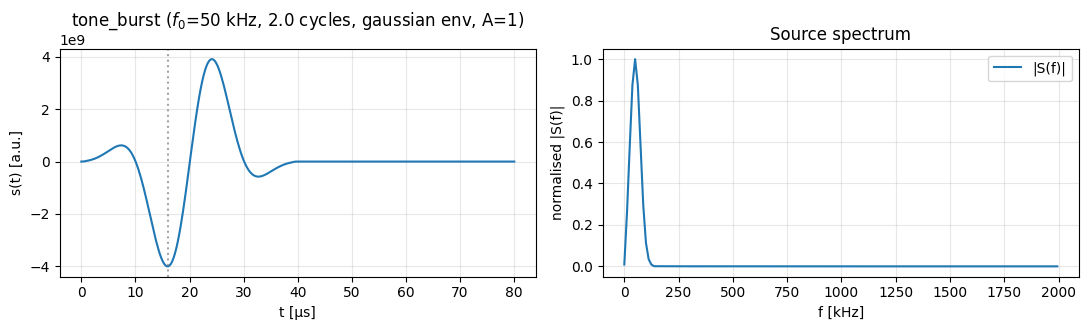

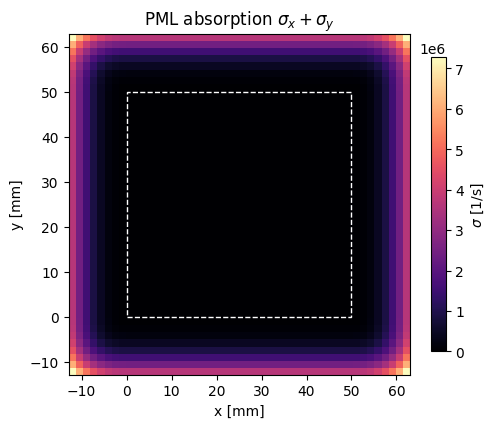

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
source.plot_pulse(ax=axes[0])
source.plot_spectrum(ax=axes[1])
plt.tight_layout(); plt.show()

grid.plot_absorption_profile(); plt.show()  # PML sigma over the full grid

## 2. Velocity models and acquisition geometry

`VelocityModel` builds `c(x, y)`. The **truth** is a small, weak circular
over-density (a ~8% sound-speed bump) at the centre of the domain, embedded in
water; the inversion **starts from a homogeneous water model** and must recover
it. `AcquisitionGeometry` lays receivers on a **circle centred on the grid** and
picks an evenly spaced subset as sources.

truth c in [1500, 1620] m/s   start c = 1500 m/s (homogeneous)
32 receivers, 16 sources


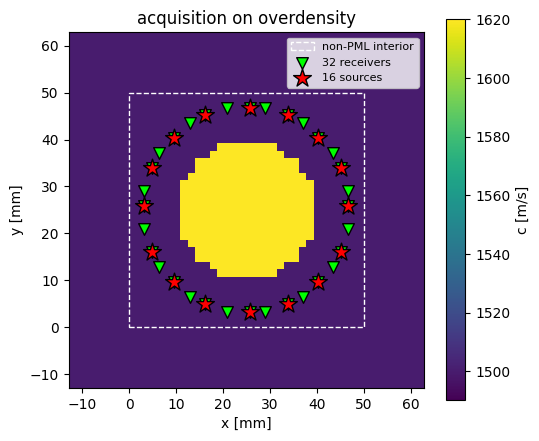

In [4]:
truth = VelocityModel(
    grid, profile='overdensity', base=1500.0, contrast=120.0,
    radius=0.015, center=(0.025, 0.025), pml_fill='edge',
)
init = VelocityModel(grid, profile='homogeneous', base=1500.0, pml_fill='edge')
print(f'truth c in [{truth.c_min:.0f}, {truth.c_max:.0f}] m/s   '
      f'start c = {init.c_min:.0f} m/s (homogeneous)')

# Receivers on a circle centred on the grid (a_frac == b_frac), sources an
# evenly spaced subset. The same layout is reused for every band, so define its
# parameters once.
(x0, x1), (y0, y1) = grid.extent
ring_center = ((x0 + x1) / 2.0, (y0 + y1) / 2.0)   # "grid_center"
ACQ = dict(
    n_receivers=32, n_sources=16, source_spatial='point',
    ring_center=ring_center, a_frac=0.9, b_frac=0.9,   # circular ring
)

# One geometry per frequency; build one here just to visualise the layout.
freq0 = FrequencySelection.from_frequencies(grid, [50e3])
geom0 = AcquisitionGeometry(grid, source, freq0, **ACQ)
print(f'{geom0.n_receivers} receivers, {geom0.n_sources} sources')
geom0.show(truth, vmin=1490, vcenter=1555, vmax=1620); plt.show()

## 3. Forward modelling — synthesising the observed data

`HelmholtzSolver` factorises `H(c, ω)` once and solves every shot. Running it on
the **truth** model produces the observations `d_obs` the inversion will fit.
(In practice one would generate data with a different solver/grid to avoid the
*inverse crime*; here a single Helmholtz solve keeps the demo self-contained.)

16 observed shots, each amplitude (1, 48, 48)


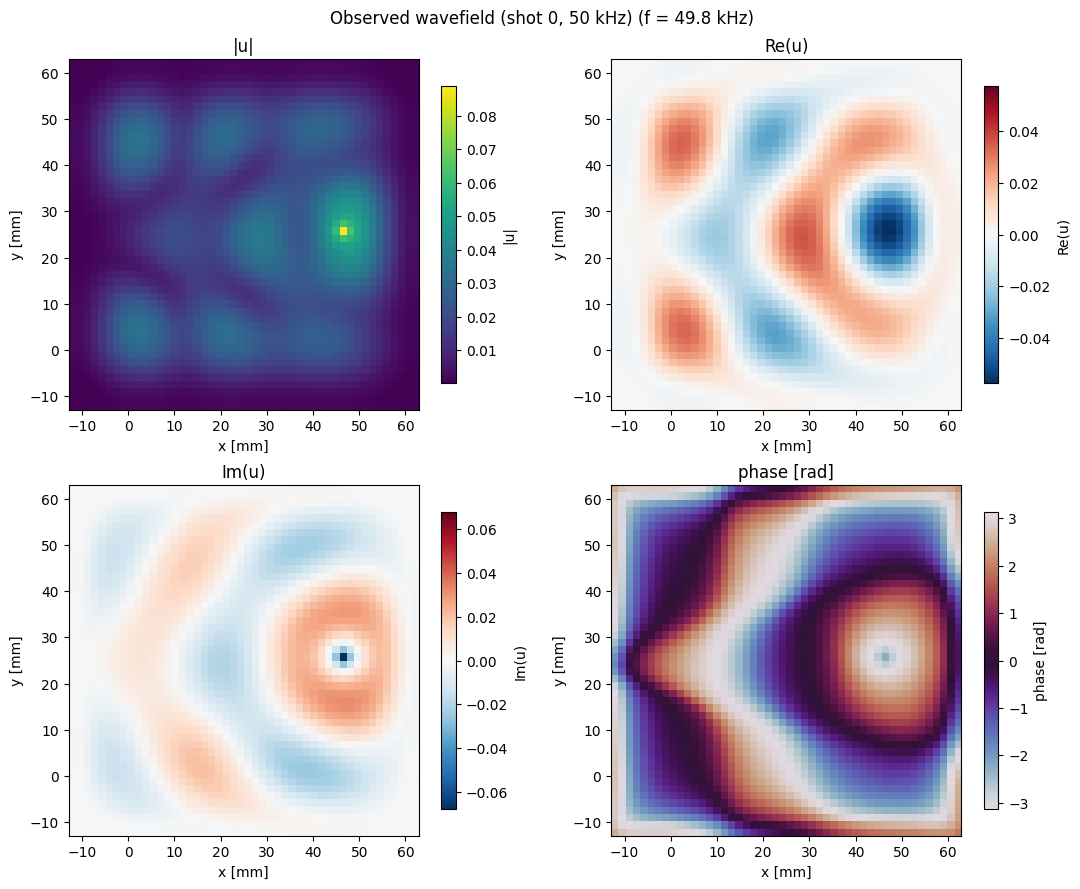

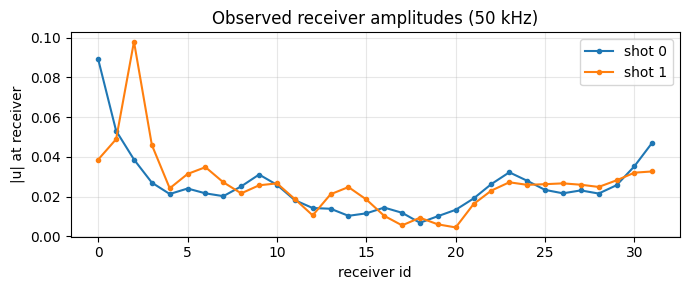

In [5]:
observed = HelmholtzSolver(
    Wavefield(grid, freq0, velocity_model=truth), geom0, space_order=4,
).solve(verbose=False)
print(f'{len(observed)} observed shots, each amplitude {tuple(observed[0].amplitude.shape)}')

# Complex wavefield of shot 0 (magnitude / real / imag / phase).
observed[0].show(0, title='Observed wavefield (shot 0, 50 kHz)')

# geometry.extract_observations pulls the receiver samples that the data
# misfit is computed on; plot |u| at each receiver for the first two shots.
fig, ax = plt.subplots(figsize=(7, 3))
for s in range(2):
    d = geom0.extract_observations(observed[s].amplitude)[0].abs().cpu().numpy()
    ax.plot(d, marker='o', ms=3, label=f'shot {s}')
ax.set_xlabel('receiver id'); ax.set_ylabel('|u| at receiver')
ax.set_title('Observed receiver amplitudes (50 kHz)'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. The inverse problem

For one band we build an `InverseLoss` (PDE residual + receiver data misfit) and
hand it to `LBFGSB`, a block-coordinate dual L-BFGS that alternates a wavefield
update (here the exact frozen-`c` solve, `u_solve='exact'`) with an L-BFGS step
on `c`. We drive it with **frequency continuation**: solve low frequencies first
(robust, low-resolution), then warm-start each higher band from the recovered
model. A single shared `LossTape` records the loss across all bands.

In [6]:
def rel_c_error(model, ref):
    """Relative L2 velocity error on the interior (excludes the PML)."""
    a = model.c[grid.interior_slice].cpu().numpy()
    b = ref.c[grid.interior_slice].cpu().numpy()
    return float(np.linalg.norm(a - b) / np.linalg.norm(b))


BANDS_HZ = [25e3, 40e3, 55e3, 70e3]
tape = LossTape()
current = init
rel_history = [rel_c_error(current, truth)]
print(f'start        rel_c_error = {rel_history[0]:.4f}')

for f_hz in BANDS_HZ:
    freq = FrequencySelection.from_frequencies(grid, [f_hz])
    geom = AcquisitionGeometry(grid, source, freq, **ACQ)
    # Observations for this band, from the truth model.
    obs = HelmholtzSolver(
        Wavefield(grid, freq, velocity_model=truth), geom, space_order=4,
    ).solve(verbose=False)

    # Wavefield we optimise, warm-started at the current model's Helmholtz field.
    wf = Wavefield(grid, freq, velocity_model=current)
    u_init = HelmholtzSolver(wf, geom, space_order=4).solve(verbose=False)

    loss = InverseLoss(
        observed_wavefield=obs,
        config=LossConfig(
            wave_eq=WaveEquation(wf, space_order=4),
            geometry=geom,
            weights={'pde': 1.0, 'data': 1000.0},
        ),
        callback=tape,
        normalize_data='per_receiver',
    )
    opt = LBFGSB(
        wf, loss, clamp=True, u_init=u_init,
        n_iter=25, u_steps=10, u_solve='exact',
        c_steps=1, c_lr=1.5, c_max_iter=6, max_iter=20,
    )
    recovered_wfs, _ = opt.minimise()
    current = recovered_wfs[0].velocity_model

    err = rel_c_error(current, truth)
    rel_history.append(err)
    tape.history.setdefault('rel_c_error', []).append(err)
    print(f'after {f_hz/1e3:4.0f} kHz  rel_c_error = {err:.4f}   c_max = {current.c_max:.0f} m/s')

recovered = current

start        rel_c_error = 0.0401


Iteration: 0 | loss = 3.020580e-04 | |r_pde|/|src| = 7.140e-03
Iteration: 1 | loss = 1.008771e-04 | |r_pde|/|src| = 4.721e-03


Iteration: 2 | loss = 6.442859e-05 | |r_pde|/|src| = 4.242e-03
Iteration: 3 | loss = 5.413261e-05 | |r_pde|/|src| = 3.999e-03


Iteration: 4 | loss = 5.104603e-05 | |r_pde|/|src| = 3.894e-03
Iteration: 5 | loss = 4.848704e-05 | |r_pde|/|src| = 3.798e-03


Iteration: 6 | loss = 4.614938e-05 | |r_pde|/|src| = 3.708e-03
Iteration: 7 | loss = 4.396484e-05 | |r_pde|/|src| = 3.620e-03


...

Iteration: 16 | loss = 4.870422e-06 | |r_pde|/|src| = 9.798e-04
Iteration: 17 | loss = 4.496498e-06 | |r_pde|/|src| = 9.410e-04


Iteration: 18 | loss = 4.150870e-06 | |r_pde|/|src| = 9.038e-04
Iteration: 19 | loss = 3.832332e-06 | |r_pde|/|src| = 8.681e-04


Iteration: 20 | loss = 3.539728e-06 | |r_pde|/|src| = 8.341e-04
Iteration: 21 | loss = 3.271795e-06 | |r_pde|/|src| = 8.018e-04


Iteration: 22 | loss = 3.027104e-06 | |r_pde|/|src| = 7.711e-04


Iteration: 23 | loss = 2.804083e-06 | |r_pde|/|src| = 7.538e-04
Iteration: 24 | loss = 2.461188e-06 | |r_pde|/|src| = 7.025e-04
after   70 kHz  rel_c_error = 0.0105   c_max = 1633 m/s


## 5. Results

The loss falls across the continuation and the over-density emerges from the
homogeneous start. `LossTape` provides the convergence and recovery plots.

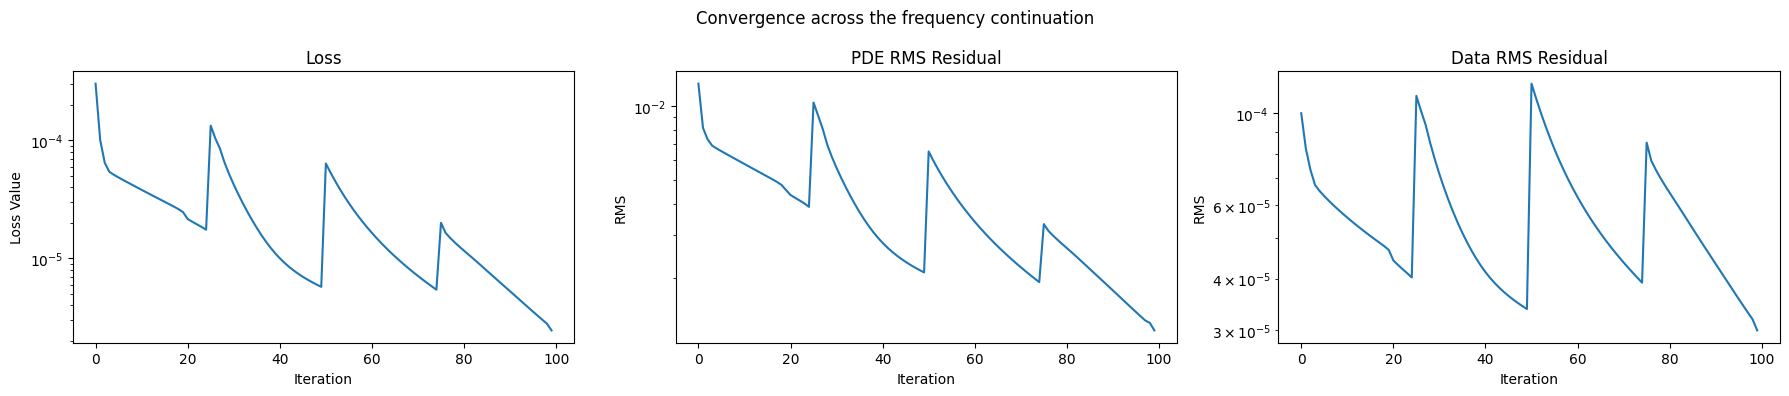

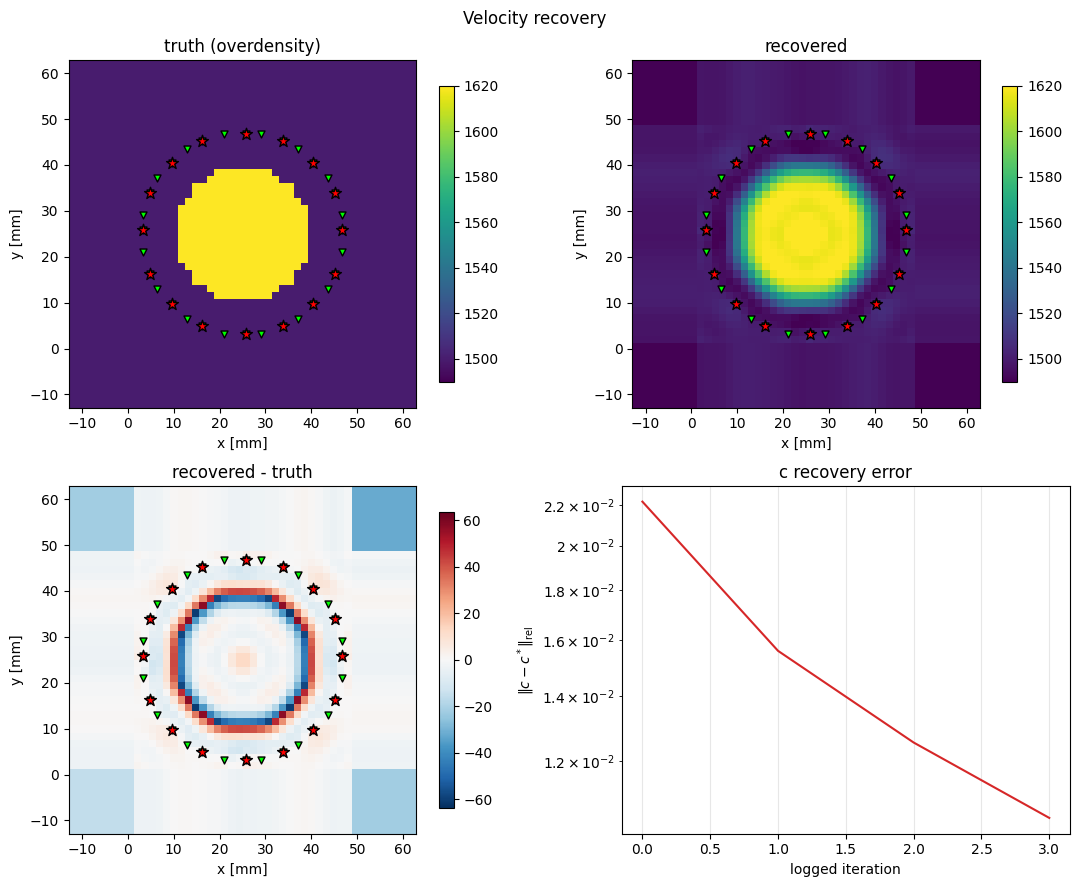

In [7]:
tape.show(title='Convergence across the frequency continuation')
tape.show_velocity_recovery(
    truth, recovered, geom0, title='Velocity recovery',
    vmin=1490, vcenter=1555, vmax=1620,
)

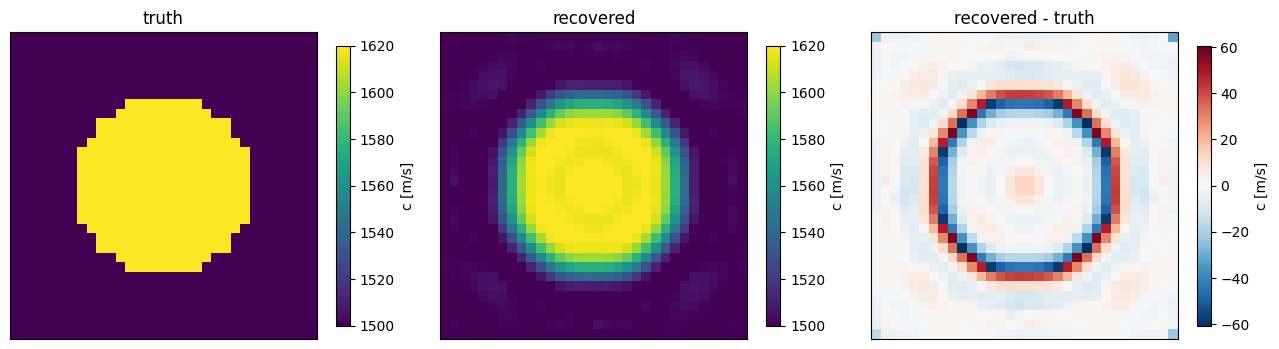

final interior rel_c_error: 0.0105 (started at 0.0401)


In [8]:
# Interior-only truth / recovered / difference.
sl = grid.interior_slice
c_true = truth.c[sl].cpu().numpy().T
c_rec = recovered.c[sl].cpu().numpy().T
diff = c_rec - c_true
dmax = float(np.abs(diff).max()) + 1e-9

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, field, ttl, kw in [
    (axes[0], c_true, 'truth', dict(cmap='viridis', vmin=1500, vmax=1620)),
    (axes[1], c_rec, 'recovered', dict(cmap='viridis', vmin=1500, vmax=1620)),
    (axes[2], diff, 'recovered - truth', dict(cmap='RdBu_r', vmin=-dmax, vmax=dmax)),
]:
    im = ax.imshow(field, origin='lower', **kw)
    ax.set_title(ttl); ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, shrink=0.8, label='c [m/s]')
plt.tight_layout(); plt.show()

print(f'final interior rel_c_error: {rel_history[-1]:.4f} '
      f'(started at {rel_history[0]:.4f})')